In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

In [3]:
from keras.layers import Conv2D # to add convolutional layers
from keras.layers import MaxPooling2D # to add pooling layers
from keras.layers import Flatten # to flatten data for fully connected layers

In [4]:
# import data
from keras.datasets import mnist

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape to be [samples][pixels][width][height]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

In [5]:
X_train = X_train / 255 # normalize training data
X_test = X_test / 255 # normalize test data

In [6]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1] # number of categories

In [7]:
def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), strides=(1, 1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

In [8]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/10
300/300 - 3s - 12ms/step - accuracy: 0.9236 - loss: 0.2726 - val_accuracy: 0.9714 - val_loss: 0.0970
Epoch 2/10
300/300 - 3s - 10ms/step - accuracy: 0.9752 - loss: 0.0862 - val_accuracy: 0.9816 - val_loss: 0.0601
Epoch 3/10
300/300 - 3s - 10ms/step - accuracy: 0.9823 - loss: 0.0600 - val_accuracy: 0.9824 - val_loss: 0.0541
Epoch 4/10
300/300 - 3s - 10ms/step - accuracy: 0.9856 - loss: 0.0469 - val_accuracy: 0.9850 - val_loss: 0.0484
Epoch 5/10
300/300 - 3s - 9ms/step - accuracy: 0.9878 - loss: 0.0391 - val_accuracy: 0.9848 - val_loss: 0.0484
Epoch 6/10
300/300 - 3s - 10ms/step - accuracy: 0.9902 - loss: 0.0312 - val_accuracy: 0.9865 - val_loss: 0.0392
Epoch 7/10
300/300 - 3s - 10ms/step - accuracy: 0.9914 - loss: 0.0284 - val_accuracy: 0.9877 - val_loss: 0.0417
Epoch 8/10
300/300 - 3s - 10ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9890 - val_loss: 0.0352
Epoch 9/10
300/300 - 3s - 10ms/step - accuracy: 0.9942 - loss: 0.0190 - val_accuracy: 0.9881 - val_loss: 

In [9]:
def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Conv2D(8, (2, 2), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

In [10]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/10
300/300 - 4s - 13ms/step - accuracy: 0.8777 - loss: 0.4447 - val_accuracy: 0.9681 - val_loss: 0.1122
Epoch 2/10
300/300 - 3s - 11ms/step - accuracy: 0.9684 - loss: 0.1043 - val_accuracy: 0.9788 - val_loss: 0.0688
Epoch 3/10
300/300 - 3s - 11ms/step - accuracy: 0.9769 - loss: 0.0763 - val_accuracy: 0.9831 - val_loss: 0.0552
Epoch 4/10
300/300 - 3s - 10ms/step - accuracy: 0.9812 - loss: 0.0612 - val_accuracy: 0.9835 - val_loss: 0.0497
Epoch 5/10
300/300 - 3s - 10ms/step - accuracy: 0.9834 - loss: 0.0538 - val_accuracy: 0.9852 - val_loss: 0.0437
Epoch 6/10
300/300 - 3s - 10ms/step - accuracy: 0.9855 - loss: 0.0468 - val_accuracy: 0.9852 - val_loss: 0.0468
Epoch 7/10
300/300 - 3s - 10ms/step - accuracy: 0.9876 - loss: 0.0410 - val_accuracy: 0.9863 - val_loss: 0.0400
Epoch 8/10
300/300 - 3s - 11ms/step - accuracy: 0.9886 - loss: 0.0366 - val_accuracy: 0.9870 - val_loss: 0.0393
Epoch 9/10
300/300 - 3s - 11ms/step - accuracy: 0.9898 - loss: 0.0346 - val_accuracy: 0.9869 - val_loss:

In [11]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=1024, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/10
59/59 - 3s - 46ms/step - accuracy: 0.6615 - loss: 1.2871 - val_accuracy: 0.8983 - val_loss: 0.3727
Epoch 2/10
59/59 - 2s - 37ms/step - accuracy: 0.9159 - loss: 0.2868 - val_accuracy: 0.9456 - val_loss: 0.1988
Epoch 3/10
59/59 - 2s - 37ms/step - accuracy: 0.9461 - loss: 0.1830 - val_accuracy: 0.9607 - val_loss: 0.1416
Epoch 4/10
59/59 - 2s - 37ms/step - accuracy: 0.9602 - loss: 0.1365 - val_accuracy: 0.9679 - val_loss: 0.1087
Epoch 5/10
59/59 - 2s - 37ms/step - accuracy: 0.9677 - loss: 0.1099 - val_accuracy: 0.9724 - val_loss: 0.0901
Epoch 6/10
59/59 - 2s - 37ms/step - accuracy: 0.9729 - loss: 0.0931 - val_accuracy: 0.9756 - val_loss: 0.0784
Epoch 7/10
59/59 - 2s - 39ms/step - accuracy: 0.9761 - loss: 0.0805 - val_accuracy: 0.9788 - val_loss: 0.0669
Epoch 8/10
59/59 - 2s - 38ms/step - accuracy: 0.9788 - loss: 0.0716 - val_accuracy: 0.9811 - val_loss: 0.0617
Epoch 9/10
59/59 - 2s - 37ms/step - accuracy: 0.9801 - loss: 0.0655 - val_accuracy: 0.9797 - val_loss: 0.0594
Epoch 10/1

In [12]:
# Write your answer here

# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=1024, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/25
59/59 - 3s - 52ms/step - accuracy: 0.6546 - loss: 1.2598 - val_accuracy: 0.8894 - val_loss: 0.3898
Epoch 2/25
59/59 - 2s - 39ms/step - accuracy: 0.9076 - loss: 0.3140 - val_accuracy: 0.9333 - val_loss: 0.2308
Epoch 3/25
59/59 - 2s - 39ms/step - accuracy: 0.9395 - loss: 0.2069 - val_accuracy: 0.9531 - val_loss: 0.1589
Epoch 4/25
59/59 - 2s - 38ms/step - accuracy: 0.9560 - loss: 0.1491 - val_accuracy: 0.9644 - val_loss: 0.1195
Epoch 5/25
59/59 - 2s - 37ms/step - accuracy: 0.9657 - loss: 0.1168 - val_accuracy: 0.9712 - val_loss: 0.0945
Epoch 6/25
59/59 - 2s - 38ms/step - accuracy: 0.9710 - loss: 0.0971 - val_accuracy: 0.9743 - val_loss: 0.0842
Epoch 7/25
59/59 - 2s - 37ms/step - accuracy: 0.9746 - loss: 0.0842 - val_accuracy: 0.9778 - val_loss: 0.0716
Epoch 8/25
59/59 - 2s - 37ms/step - accuracy: 0.9773 - loss: 0.0753 - val_accuracy: 0.9799 - val_loss: 0.0665
Epoch 9/25
59/59 - 2s - 37ms/step - accuracy: 0.9792 - loss: 0.0695 - val_accuracy: 0.9812 - val_loss: 0.0607
Epoch 10/2

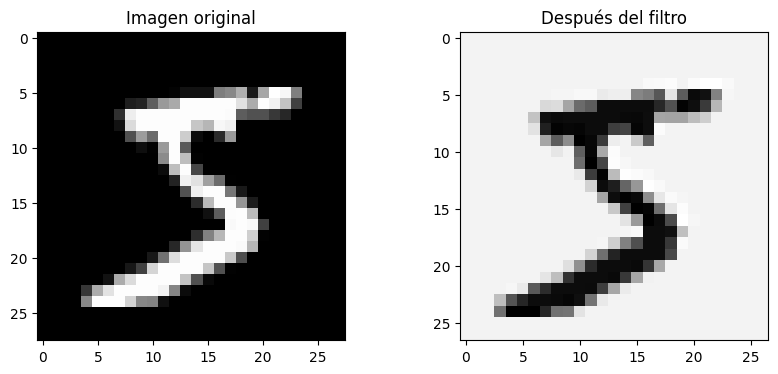

In [30]:
import numpy as np
import matplotlib.pyplot as plt

imagen = X_train[0].squeeze()

filtro = np.array([
    [0, -20],
    [1, 0]
])

alto, ancho = imagen.shape
salida = np.zeros((alto - 1, ancho - 1))

for i in range(alto - 1):
    for j in range(ancho - 1):
        region = imagen[i:i+2, j:j+2]
        salida[i, j] = np.sum(region * filtro)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")

plt.subplot(1, 2, 2)
plt.imshow(salida, cmap="gray")
plt.title("Después del filtro")

plt.show()

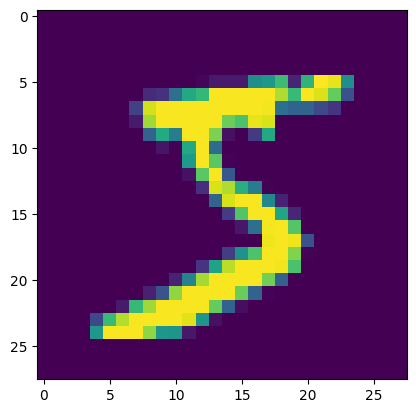

In [31]:
plt.imshow(imagen)

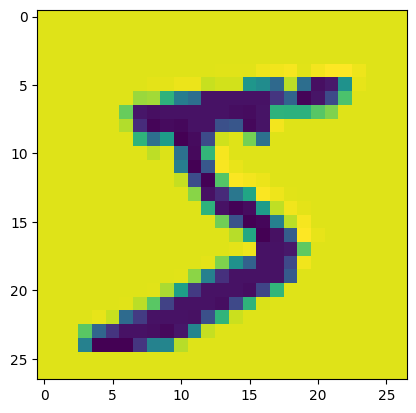

In [32]:
plt.imshow(salida)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Max Pooling 2x2
alto, ancho = salida.shape

alto_pool = alto // 2
ancho_pool = ancho // 2

pooling = np.zeros((alto_pool, ancho_pool))

for i in range(alto_pool):
    for j in range(ancho_pool):
        
        region = salida[
            i*2:i*2+2,
            j*2:j*2+2
        ]

        pooling[i, j] = np.max(region)

In [34]:
np.max(region)

np.float64(0.0)

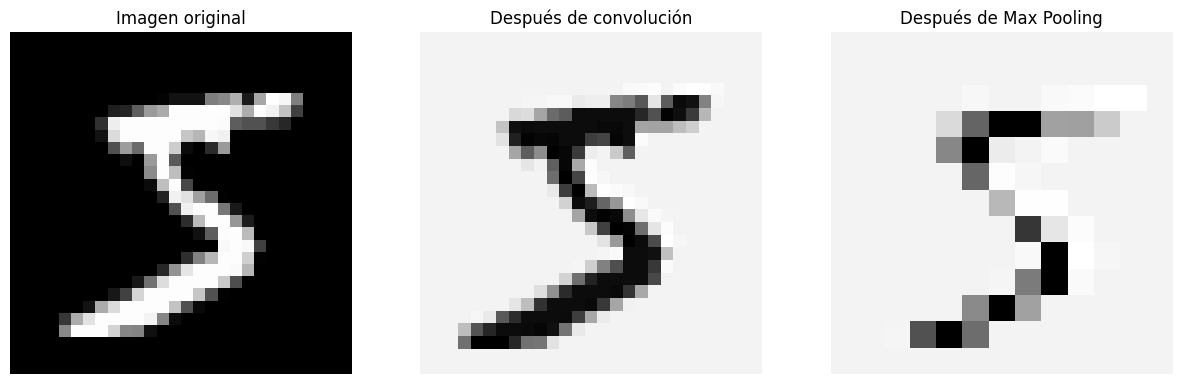

In [35]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(salida, cmap="gray")
plt.title("Después de convolución")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pooling, cmap="gray")
plt.title("Después de Max Pooling")
plt.axis("off")

plt.show()